C:\Users\b_o_x\AppData\Local\Temp\ipykernel_16948\3237465466.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(consulta, conexion)


Datos cargados:
            Total_Ventas
Periodo                 
2021-01-01   42869419.39
2021-02-01   40164080.07
2021-03-01   43394863.31
2021-04-01   42219200.64
2021-05-01   43943449.44

Cantidad de periodos: 59

Train: 2021-01-01 00:00:00 a 2025-05-01 00:00:00
Test: 2025-06-01 00:00:00 a 2025-11-01 00:00:00

Entrenando: Exp_1_ARIMA_simple

Entrenando: Exp_2_SARIMA_base

Entrenando: Exp_3_SARIMA_amplio

Resumen de experimentación:
           experimento  seasonal   m orden_modelo orden_estacional  \
0   Exp_1_ARIMA_simple     False   1    (1, 0, 0)     (0, 0, 0, 0)   
1    Exp_2_SARIMA_base      True  12    (0, 0, 1)    (0, 0, 2, 12)   
2  Exp_3_SARIMA_amplio      True  12    (0, 0, 1)    (0, 0, 2, 12)   

             MAE          RMSE      MAPE  
0  944899.579911  1.067068e+06  2.230273  
1  934690.322229  1.134592e+06  2.219590  
2  934690.322229  1.134592e+06  2.219590  

Mejor modelo:
experimento         Exp_1_ARIMA_simple
seasonal                         False
m             

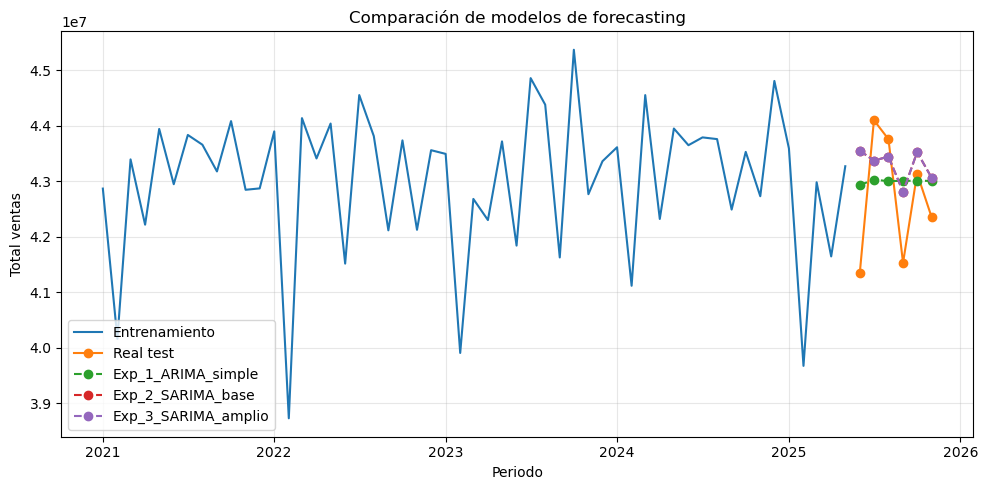


Forecast final:
              Periodo  Forecast_Ventas
2025-12-01 2025-12-01     4.317128e+07
2026-01-01 2026-01-01     4.292430e+07
2026-02-01 2026-02-01     4.299866e+07
2026-03-01 2026-03-01     4.297627e+07
2026-04-01 2026-04-01     4.298301e+07
2026-05-01 2026-05-01     4.298098e+07

Archivos generados:
resultados_experimentacion_forecasting.xlsx
forecast_ventas.xlsx
comparacion_forecasting.png


In [1]:
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pmdarima.arima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# 1. CONEXIÓN
# =========================
conexion = pyodbc.connect(
    r"Driver={SQL Server};"
    r"Server=DESKTOP-SDA345T\SQLEXPRESS;"
    r"Database=tpcxbb_1gb;"
    r"Trusted_Connection=yes;"
)

# =========================
# 2. QUERY BASE
# =========================
consulta = """
SELECT 
    CAST(YEAR(DATEADD(YEAR, 20, d.d_date)) AS VARCHAR) + '-' + 
    RIGHT('0' + CAST(MONTH(DATEADD(YEAR, 20, d.d_date)) AS VARCHAR), 2) AS Periodo,
    SUM(s.ss_quantity * s.ss_list_price) AS Total_Ventas
FROM store_sales s
INNER JOIN date_dim d 
    ON s.ss_sold_date_sk = d.d_date_sk
WHERE NOT (
    YEAR(d.d_date) = 2005 
    AND MONTH(d.d_date) = 12
)
GROUP BY 
    YEAR(DATEADD(YEAR, 20, d.d_date)),
    MONTH(DATEADD(YEAR, 20, d.d_date))
ORDER BY 
    MIN(DATEADD(YEAR, 20, d.d_date))
"""

df = pd.read_sql(consulta, conexion)
conexion.close()

# =========================
# 3. PREPARACIÓN
# =========================
df["Periodo"] = pd.to_datetime(df["Periodo"])
df = df.sort_values("Periodo")
df = df.set_index("Periodo")

serie = df["Total_Ventas"]

print("Datos cargados:")
print(df.head())
print("\nCantidad de periodos:", len(df))

# =========================
# 4. TRAIN / TEST
# =========================
train = serie.iloc[:-6]
test = serie.iloc[-6:]

print("\nTrain:", train.index.min(), "a", train.index.max())
print("Test:", test.index.min(), "a", test.index.max())

# =========================
# 5. EXPERIMENTOS ARIMA/SARIMA
# =========================
experimentos = [
    {
        "nombre": "Exp_1_ARIMA_simple",
        "seasonal": False,
        "m": 1,
        "max_p": 3,
        "max_q": 3,
        "max_P": 0,
        "max_Q": 0
    },
    {
        "nombre": "Exp_2_SARIMA_base",
        "seasonal": True,
        "m": 12,
        "max_p": 3,
        "max_q": 3,
        "max_P": 2,
        "max_Q": 2
    },
    {
        "nombre": "Exp_3_SARIMA_amplio",
        "seasonal": True,
        "m": 12,
        "max_p": 5,
        "max_q": 5,
        "max_P": 3,
        "max_Q": 3
    }
]

resultados = []
predicciones = {}

for exp in experimentos:

    print("\nEntrenando:", exp["nombre"])

    modelo = auto_arima(
        train,
        seasonal=exp["seasonal"],
        m=exp["m"],
        start_p=0,
        start_q=0,
        max_p=exp["max_p"],
        max_q=exp["max_q"],
        start_P=0,
        start_Q=0,
        max_P=exp["max_P"],
        max_Q=exp["max_Q"],
        d=None,
        D=None,
        trace=False,
        error_action="ignore",
        suppress_warnings=True,
        stepwise=True
    )

    pred = modelo.predict(n_periods=len(test))
    pred = pd.Series(pred, index=test.index)

    mae = mean_absolute_error(test, pred)
    rmse = np.sqrt(mean_squared_error(test, pred))
    mape = np.mean(np.abs((test - pred) / test)) * 100

    resultados.append({
        "experimento": exp["nombre"],
        "seasonal": exp["seasonal"],
        "m": exp["m"],
        "orden_modelo": str(modelo.order),
        "orden_estacional": str(modelo.seasonal_order),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

    predicciones[exp["nombre"]] = pred

resultados_df = pd.DataFrame(resultados)

print("\nResumen de experimentación:")
print(resultados_df.sort_values("RMSE"))

# =========================
# 6. MEJOR MODELO
# =========================
mejor = resultados_df.sort_values("RMSE").iloc[0]
mejor_nombre = mejor["experimento"]

print("\nMejor modelo:")
print(mejor)

# =========================
# 7. GRÁFICO COMPARACIÓN
# =========================
plt.figure(figsize=(10, 5))

plt.plot(train.index, train, label="Entrenamiento")
plt.plot(test.index, test, marker="o", label="Real test")

for nombre, pred in predicciones.items():
    plt.plot(pred.index, pred, marker="o", linestyle="--", label=nombre)

plt.title("Comparación de modelos de forecasting")
plt.xlabel("Periodo")
plt.ylabel("Total ventas")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("comparacion_forecasting.png", dpi=300)
plt.show()

# =========================
# 8. FORECAST FINAL
# =========================
modelo_final = auto_arima(
    serie,
    seasonal=mejor["seasonal"],
    m=int(mejor["m"]),
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    start_P=0,
    start_Q=0,
    max_P=3,
    max_Q=3,
    d=None,
    D=None,
    trace=False,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

forecast_periodos = 6
forecast = modelo_final.predict(n_periods=forecast_periodos)

fechas_futuras = pd.date_range(
    start=serie.index.max() + pd.DateOffset(months=1),
    periods=forecast_periodos,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "Periodo": fechas_futuras,
    "Forecast_Ventas": forecast
})

print("\nForecast final:")
print(forecast_df)

# =========================
# 9. EXPORTAR
# =========================
resultados_df.to_excel("resultados_experimentacion_forecasting.xlsx", index=False)
forecast_df.to_excel("forecast_ventas.xlsx", index=False)

print("\nArchivos generados:")
print("resultados_experimentacion_forecasting.xlsx")
print("forecast_ventas.xlsx")
print("comparacion_forecasting.png")